# IX. Day-0 Risk Clustering

Notebook centrado en una sola pregunta: si con las variables de `day0_static_features.csv` se puede detectar ya en el día 0 un grupo con mayor riesgo académico.

Principios de este notebook:
- solo usa features de day 0
- no usa AE ni PCA
- entrena un único clustering en training y lo aplica a validation/test
- reetiqueta los clusters por nivel de riesgo usando `final_result` en training para que el grupo 0 sea el más crítico
- genera visualizaciones tipo dashboard para ver cómo se distribuyen los resultados por grupo

In [7]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

try:
    from educational_ai_analytics.config import FEATURES_DATA_DIR, N_CLUSTERS, PROJ_ROOT
    PROJECT_ROOT = Path(PROJ_ROOT)
    FEATURES_ROOT = Path(FEATURES_DATA_DIR)
    CLUSTERS = int(N_CLUSTERS)
except ImportError:
    PROJECT_ROOT = Path('/workspace/TFM_education_ai_analytics')
    FEATURES_ROOT = PROJECT_ROOT / 'data' / '3_features'
    CLUSTERS = 5

SPLITS = ['training', 'validation', 'test']
FEATURE_FILE = 'day0_static_features.csv'
TARGET_FILE = 'target.csv'
TARGET_COL = 'final_result'
RANDOM_STATE = 42
USE_STANDARD_SCALER = True

DARK_BG = '#0F1117'
PANEL_BG = '#1A1D27'
GRID_CLR = '#2A2D3A'
TEXT_CLR = '#E8EAED'

LABELS_MAP = {3: 'Distinction', 2: 'Pass', 1: 'Fail', 0: 'Withdrawn'}
COLORS_MAP = {3: '#4FD1A1', 2: '#76B7EB', 1: '#F6BD60', 0: '#F25F5C'}

plt.rcParams.update({
    'figure.facecolor': DARK_BG,
    'axes.facecolor': PANEL_BG,
    'text.color': TEXT_CLR,
    'axes.labelcolor': TEXT_CLR,
    'xtick.color': TEXT_CLR,
    'ytick.color': TEXT_CLR,
    'axes.edgecolor': GRID_CLR,
    'grid.color': GRID_CLR,
    'grid.linestyle': '--',
    'grid.alpha': 0.35,
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],
})

def style_axis(ax):
    ax.set_facecolor(PANEL_BG)
    ax.grid(True, axis='y', alpha=0.25)
    for spine in ax.spines.values():
        spine.set_color(GRID_CLR)

def cluster_names(n_clusters: int):
    base = [
        'Riesgo crítico (day0)',
        'Perfil intermedio A',
        'Perfil intermedio B',
        'Perfil intermedio C',
        'Alto rendimiento (day0)',
    ]
    if n_clusters <= len(base):
        return base[:n_clusters]
    extra = [f'Grupo {i}' for i in range(len(base), n_clusters)]
    return base + extra

CLUSTER_NAMES = cluster_names(CLUSTERS)

print(f'Project root: {PROJECT_ROOT}')
print(f'Features root: {FEATURES_ROOT}')
print(f'Clustering: KMeans | clusters={CLUSTERS} | scaler={USE_STANDARD_SCALER}')

Project root: /workspace/TFM_education_ai_analytics
Features root: /workspace/TFM_education_ai_analytics/data/3_features
Clustering: KMeans | clusters=5 | scaler=True


In [8]:
def load_day0_split(split: str):
    feature_path = FEATURES_ROOT / split / FEATURE_FILE
    target_path = FEATURES_ROOT / split / TARGET_FILE

    df_x = pd.read_csv(feature_path, index_col=0)
    df_y = pd.read_csv(target_path, index_col=0)

    common_index = df_x.index.intersection(df_y.index)
    df_x = df_x.loc[common_index].copy()
    df_y = df_y.loc[common_index].copy()

    df_x = df_x.select_dtypes(include=[np.number]).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    y = df_y[TARGET_COL].astype(int)
    return df_x, y

split_data = {}
for split in SPLITS:
    X_split, y_split = load_day0_split(split)
    split_data[split] = {'X': X_split, 'y': y_split}

feature_columns = split_data['training']['X'].columns.tolist()
for split in SPLITS[1:]:
    split_data[split]['X'] = split_data[split]['X'].reindex(columns=feature_columns, fill_value=0.0)

overview_rows = []
for split in SPLITS:
    y_split = split_data[split]['y']
    overview_rows.append({
        'split': split,
        'n_students': len(y_split),
        'n_features_day0': split_data[split]['X'].shape[1],
        'withdrawn_rate': float((y_split == 0).mean()),
        'success_rate': float((y_split >= 2).mean()),
    })

display(Markdown('### Datos cargados'))
display(pd.DataFrame(overview_rows))
print('Primeras columnas day0:', feature_columns[:12])

### Datos cargados

,split,n_students,n_features_day0,withdrawn_rate,success_rate
0,training,22785,13,0.311828,0.471012
1,validation,4889,13,0.314788,0.470239
2,test,4919,13,0.307380,0.478553


Primeras columnas day0: ['imd_band', 'age_band', 'highest_education', 'num_of_prev_attempts', 'studied_credits', 'region_encoded', 'prestart_clicks_total', 'prestart_active_days', 'prestart_active_weeks', 'prestart_earliest_day', 'investigated_platform', 'prestart_intensity']


In [3]:
X_train = split_data['training']['X'].values.astype(np.float32)
y_train = split_data['training']['y']

scaler = StandardScaler() if USE_STANDARD_SCALER else None
X_train_model = scaler.fit_transform(X_train) if scaler is not None else X_train

clusterer = KMeans(
    n_clusters=CLUSTERS,
    n_init=20,
    max_iter=500,
    random_state=RANDOM_STATE,
)
train_labels_raw = clusterer.fit_predict(X_train_model)

risk_order = (
    pd.DataFrame({'cluster': train_labels_raw, 'final_result': y_train.values})
    .groupby('cluster')['final_result']
    .apply(lambda s: (s == 0).mean())
    .sort_values(ascending=False)
)
cluster_map = {old_cluster: new_cluster for new_cluster, old_cluster in enumerate(risk_order.index)}

def relabel_clusters(labels_raw: np.ndarray) -> np.ndarray:
    return np.array([cluster_map[int(label)] for label in labels_raw], dtype=int)

results = {}
metrics_rows = []
cluster_summary_rows = []

for split in SPLITS:
    X_df = split_data[split]['X']
    y_split = split_data[split]['y']
    X_raw = X_df.values.astype(np.float32)
    X_model = scaler.transform(X_raw) if scaler is not None else X_raw

    labels_raw = clusterer.predict(X_model)
    labels_ord = relabel_clusters(labels_raw)

    df_assign = pd.DataFrame({
        'cluster': labels_ord,
        'cluster_name': [CLUSTER_NAMES[c] for c in labels_ord],
        'final_result': y_split.values,
    }, index=X_df.index)

    results[split] = {
        'X_model': X_model,
        'labels_raw': labels_raw,
        'labels_ord': labels_ord,
        'assignments': df_assign,
    }

    if len(np.unique(labels_ord)) > 1:
        sil = float(silhouette_score(X_model, labels_ord, sample_size=min(5000, len(X_model))))
        ch = float(calinski_harabasz_score(X_model, labels_ord))
        db = float(davies_bouldin_score(X_model, labels_ord))
    else:
        sil, ch, db = np.nan, np.nan, np.nan

    metrics_rows.append({
        'split': split,
        'silhouette': sil,
        'calinski_harabasz': ch,
        'davies_bouldin': db,
        'success_rate_global': float((y_split >= 2).mean()),
        'withdrawn_rate_global': float((y_split == 0).mean()),
    })

    for cluster_id in range(CLUSTERS):
        mask = labels_ord == cluster_id
        if mask.sum() == 0:
            continue
        y_cluster = y_split.values[mask]
        cluster_summary_rows.append({
            'split': split,
            'cluster': cluster_id,
            'cluster_name': CLUSTER_NAMES[cluster_id],
            'n_students': int(mask.sum()),
            'withdrawn_rate': float((y_cluster == 0).mean()),
            'fail_rate': float((y_cluster == 1).mean()),
            'success_rate': float((y_cluster >= 2).mean()),
        })

metrics_df = pd.DataFrame(metrics_rows)
cluster_summary_df = pd.DataFrame(cluster_summary_rows)

display(Markdown('### Métricas internas del clustering'))
display(metrics_df)

display(Markdown('### Resumen de riesgo por cluster y split'))
display(cluster_summary_df.sort_values(['split', 'cluster']).reset_index(drop=True))

### Métricas internas del clustering

,split,silhouette,calinski_harabasz,davies_bouldin,success_rate_global,withdrawn_rate_global
0,training,0.180583,5541.266229,1.852986,0.471012,0.311828
1,validation,0.180747,1176.609842,1.864420,0.470239,0.314788
2,test,0.182085,1187.786822,1.857376,0.478553,0.307380


### Resumen de riesgo por cluster y split

,split,cluster,cluster_name,n_students,withdrawn_rate,fail_rate,success_rate
0,test,0,Riesgo crítico (day0),1316,0.508359,0.243921,0.247720
1,test,1,Perfil intermedio A,250,0.304000,0.344000,0.352000
2,test,2,Perfil intermedio B,1235,0.304453,0.231579,0.463968
3,test,3,Perfil intermedio C,1351,0.186528,0.179127,0.634345
4,test,4,Alto rendimiento (day0),767,0.181226,0.153846,0.664928
5,training,0,Riesgo crítico (day0),6129,0.497797,0.250938,0.251264
6,training,1,Perfil intermedio A,1294,0.307573,0.320711,0.371716
7,training,2,Perfil intermedio B,5702,0.291477,0.246931,0.461592
8,training,3,Perfil intermedio C,5932,0.207013,0.175995,0.616993
9,training,4,Alto rendimiento (day0),3728,0.205472,0.145655,0.648873


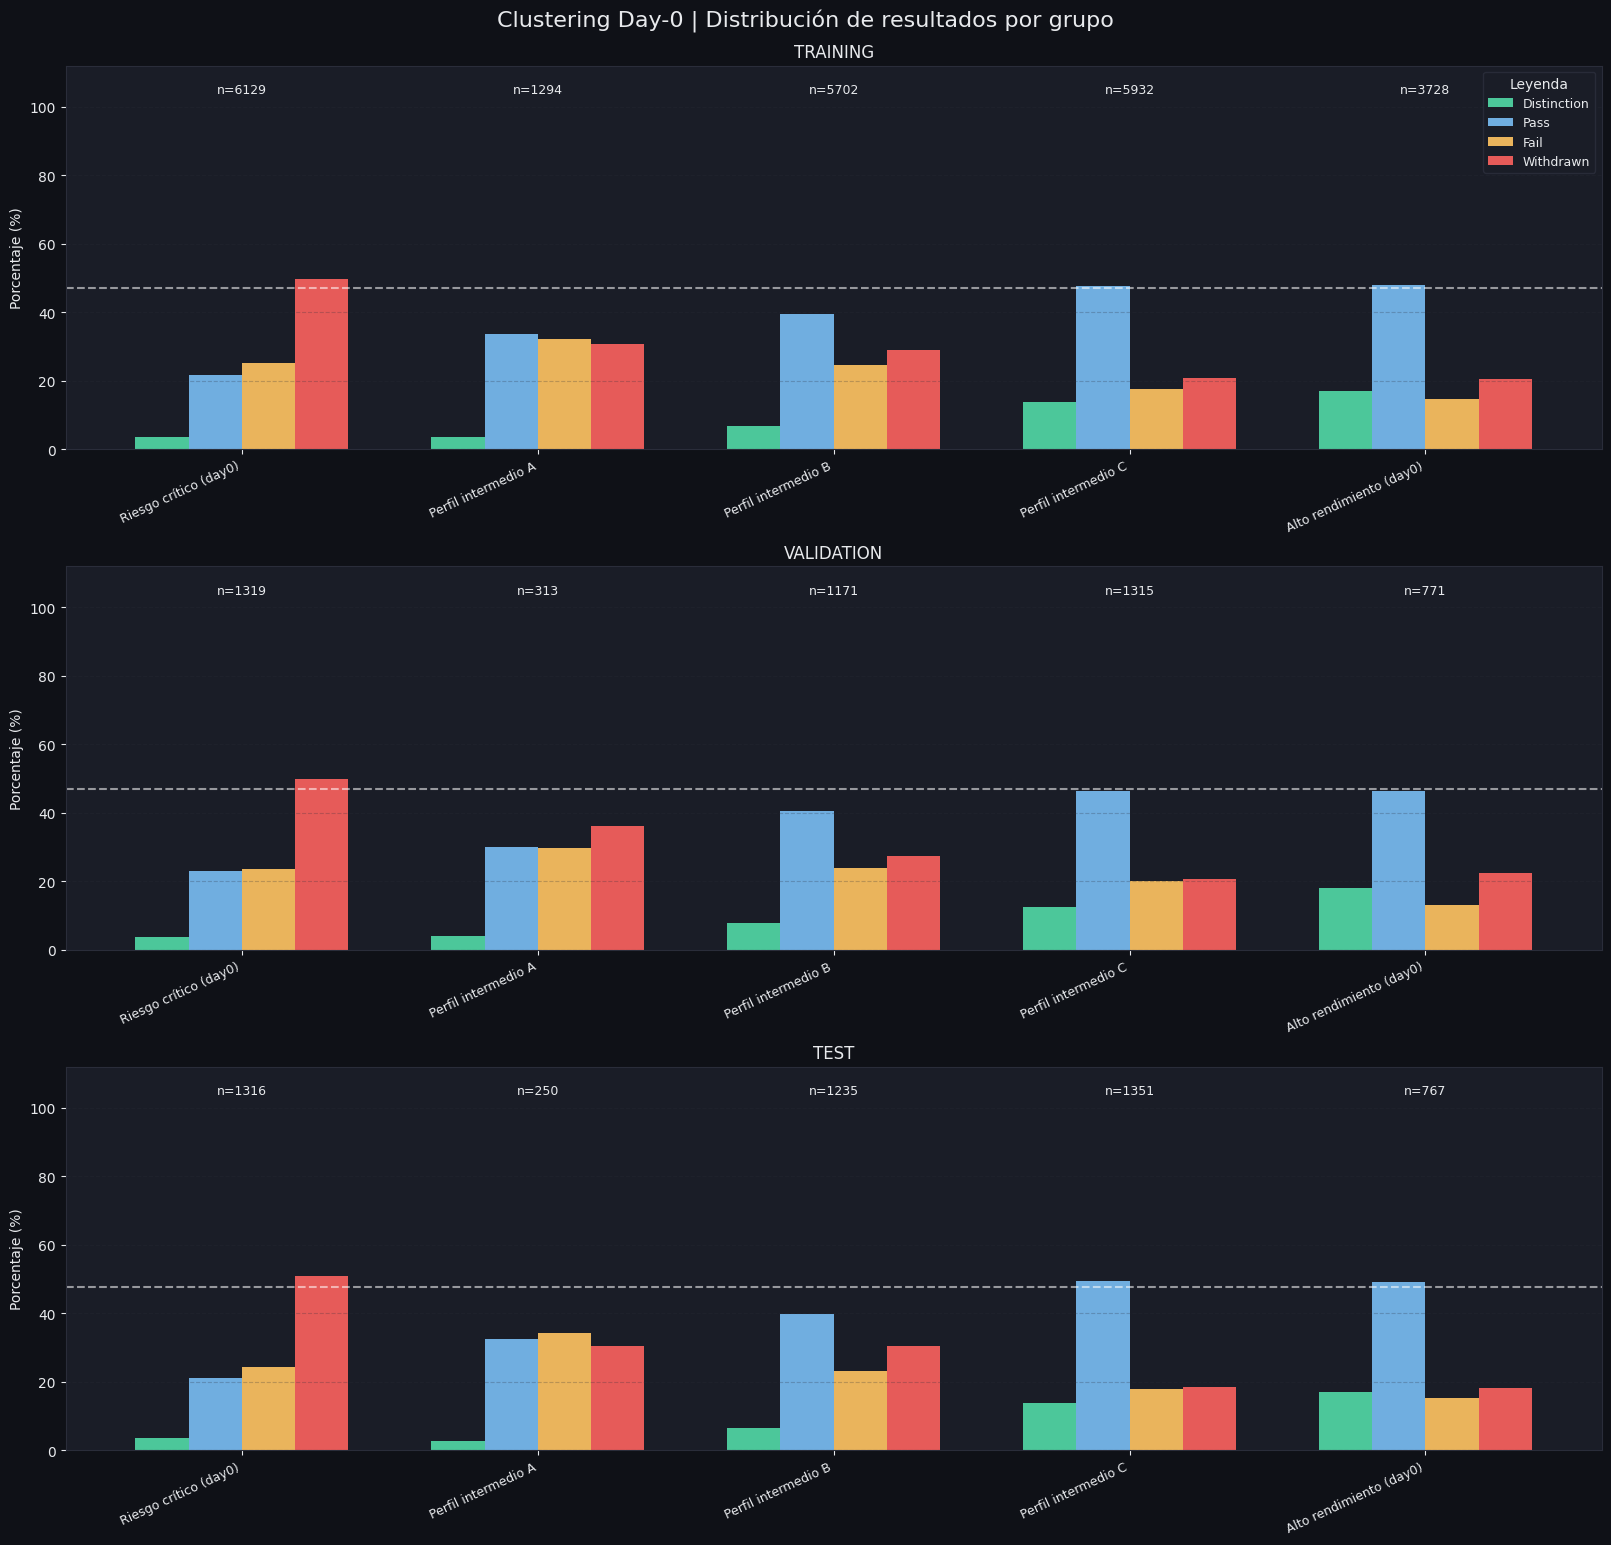

In [4]:
result_order = [3, 2, 1, 0]

fig, axes = plt.subplots(len(SPLITS), 1, figsize=(16, 5 * len(SPLITS)), constrained_layout=True)
axes = np.atleast_1d(axes)
fig.patch.set_facecolor(DARK_BG)

for ax, split in zip(axes, SPLITS):
    df_assign = results[split]['assignments']
    counts = (
        df_assign.groupby(['cluster', 'final_result'])
        .size()
        .unstack(fill_value=0)
        .reindex(index=range(CLUSTERS), fill_value=0)
        .reindex(columns=result_order, fill_value=0)
    )
    percentages = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0) * 100

    x = np.arange(CLUSTERS)
    width = 0.18
    for i, result_value in enumerate(result_order):
        label = LABELS_MAP[result_value]
        ax.bar(
            x + (i - 1.5) * width,
            percentages[result_value].values,
            width=width,
            label=label if split == SPLITS[0] else None,
            color=COLORS_MAP[result_value],
            alpha=0.95,
        )

    split_success = (df_assign['final_result'] >= 2).mean() * 100
    ax.axhline(split_success, color='white', linestyle='--', alpha=0.55)

    cluster_sizes = counts.sum(axis=1).astype(int).tolist()
    for xpos, n_students in zip(x, cluster_sizes):
        ax.text(xpos, 103.0, f'n={n_students}', ha='center', va='bottom', fontsize=9, color=TEXT_CLR)

    ax.set_title(split.upper(), fontsize=12)
    ax.set_ylabel('Porcentaje (%)')
    ax.set_ylim(0, 112)
    ax.set_xticks(x)
    ax.set_xticklabels(CLUSTER_NAMES, rotation=25, ha='right', fontsize=9)
    style_axis(ax)

legend = axes[0].legend(title='Leyenda', facecolor=PANEL_BG, edgecolor=GRID_CLR, framealpha=0.9, fontsize=9)
legend.get_title().set_color(TEXT_CLR)
for text in legend.get_texts():
    text.set_color(TEXT_CLR)

fig.suptitle('Clustering Day-0 | Distribución de resultados por grupo', fontsize=16, y=1.02)
plt.show()

### Variables day0 más discriminativas entre clusters

,z_range
num_of_prev_attempts,3.200086
prestart_active_weeks,2.224779
investigated_platform,2.223000
prestart_earliest_day,2.199718
prestart_anticipation,2.199718
age_band,2.168404
prestart_clicks_total,2.166276
prestart_intensity,2.113130
prestart_active_days,1.722451
studied_credits,0.730067


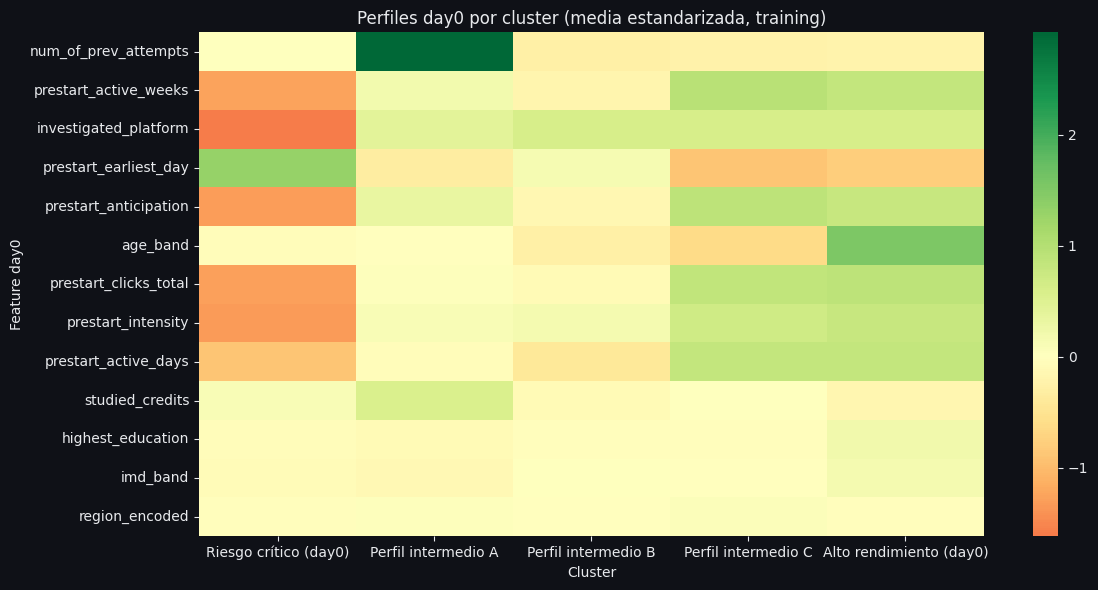

In [5]:
X_train_scaled_df = pd.DataFrame(
    results['training']['X_model'],
    index=split_data['training']['X'].index,
    columns=feature_columns,
)
X_train_scaled_df['cluster'] = results['training']['labels_ord']

cluster_profile = X_train_scaled_df.groupby('cluster').mean().sort_index()
feature_range = (cluster_profile.max(axis=0) - cluster_profile.min(axis=0)).sort_values(ascending=False)
top_features = feature_range.head(20).index.tolist()
profile_matrix = cluster_profile[top_features].T
profile_matrix.columns = [CLUSTER_NAMES[c] for c in profile_matrix.columns]

display(Markdown('### Variables day0 más discriminativas entre clusters'))
display(feature_range.head(20).rename('z_range').to_frame())

plt.figure(figsize=(12, max(6, 0.4 * len(profile_matrix))))
sns.heatmap(profile_matrix, cmap='RdYlGn', center=0.0, annot=False)
plt.title('Perfiles day0 por cluster (media estandarizada, training)')
plt.xlabel('Cluster')
plt.ylabel('Feature day0')
plt.tight_layout()
plt.show()

In [6]:
assignment_exports = []
for split in SPLITS:
    df_assign = results[split]['assignments'].copy()
    df_assign['split'] = split
    assignment_exports.append(df_assign.reset_index(names='unique_id'))

day0_cluster_assignments = pd.concat(assignment_exports, ignore_index=True)
display(Markdown('### Vista previa de asignaciones por estudiante'))
display(day0_cluster_assignments.head(20))

### Vista previa de asignaciones por estudiante

,unique_id,cluster,cluster_name,final_result,split
0,11391_AAA_2013J,2,Perfil intermedio B,2,training
1,28400_AAA_2013J,4,Alto rendimiento (day0),2,training
2,32885_AAA_2013J,3,Perfil intermedio C,2,training
3,45462_AAA_2013J,3,Perfil intermedio C,2,training
4,45642_AAA_2013J,2,Perfil intermedio B,2,training
5,53025_AAA_2013J,4,Alto rendimiento (day0),2,training
6,57506_AAA_2013J,4,Alto rendimiento (day0),2,training
7,58873_AAA_2013J,3,Perfil intermedio C,2,training
8,62155_AAA_2013J,3,Perfil intermedio C,2,training
9,70464_AAA_2013J,2,Perfil intermedio B,2,training
